# Preprocessing Steps

## Step 1: Imports and Loading

In [79]:
import pandas as pd
import numpy as np

# Model Training Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Model Evaluation Metrics Libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns

print('Imported')

Imported


In [14]:
df = pd.read_csv('../data/processed/ndsi_baseline.csv')  

print(f"Dataset shape: {df.shape}")
print(f"Total images: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

print(f"\nRegions in dataset ({df['region'].nunique()} unique):")
region_counts = df['region'].value_counts()
print(region_counts)


Dataset shape: (246, 89)
Total images: 246
Date range: 2016-12-20 to 2025-02-15

Regions in dataset (29 unique):
region
Totten_Shelf         18
Moscow_Uni_Front     18
Larsen_C_South       14
Shackleton_Front     13
Crosson_Front        12
Ross_North_West      11
Pine_Island_East     11
Ninnis_Front         10
Larsen_C_Central     10
Filchner_East        10
Totten_Front         10
Larsen_B_Remnant      9
Dotson_Front          9
Filchner_West         9
Cook_Front            9
Wilkins_North         9
Larsen_C_North        8
Pine_Island_Front     8
Thwaites_Front        7
Thwaites_East         7
Ross_East_Front       5
McMurdo_Sound         5
Ross_North_East       5
Ronne_North           4
George_VI_South       4
Fimbul_Front          4
Wilkins_South         3
Mertz_Front           3
George_VI_North       1
Name: count, dtype: int64


## Step 2: Create Retreat Labels - Based on Scientific Literature

In [37]:
# Convert 'date' from string to datetime
df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)

basename                           object
date                       datetime64[ns]
cloud_cover                       float64
satellite                          object
region                             object
                                ...      
gradient_std                      float64
gradient_max                      float64
gradient_direction_mean           float64
gradient_direction_std            float64
retreat_status                     object
Length: 90, dtype: object


In [38]:
print(f"\n{'='*80}")
print("CREATING RETREAT LABELS")
print(f"{'='*80}")

"""
Classification based on peer-reviewed Antarctic glacier research:
- Amundsen Sea Embayment glaciers (Thwaites, Pine Island): Rapid retreat
- Totten Glacier: Active retreat/thinning
- Larsen Ice Shelf remnants: Post-collapse retreat
- Ross & Filchner-Ronne: Generally stable
- Antarctic Peninsula: Variable (some retreat, some stable)
"""

GLACIER_CLASSIFICATIONS = {
    # RETREATING - High confidence (well-documented in literature)
    'Thwaites_East': 'retreating',
    'Thwaites_West': 'retreating',
    'Thwaites_Tongue': 'retreating',
    'Pine_Island_East': 'retreating',
    'Pine_Island_West': 'retreating',
    'Pine_Island_Central': 'retreating',
    'Totten_Shelf': 'retreating',
    'Totten_East': 'retreating',
    'Dotson_Front': 'retreating',
    'Crosson': 'retreating',
    'Smith': 'retreating',
    'Kohler': 'retreating',
    'Moscow_University': 'retreating',
    'Shackleton': 'retreating',
    'Denman': 'retreating',
    
    # POST-COLLAPSE RETREAT
    'Larsen_B_Remnant': 'retreating',  # After 2002 collapse
    'Larsen_A': 'retreating',  # After 1995 collapse
    
    # STABLE - High confidence
    'Ross_East': 'stable',
    'Ross_West': 'stable',
    'Ross_North_West': 'stable',
    'Ross_Central': 'stable',
    'Filchner_East': 'stable',
    'Filchner_West': 'stable',
    'Ronne_East': 'stable',
    'Ronne_West': 'stable',
    'Brunt': 'stable',
    'Riiser_Larsen': 'stable',
    
    # STABLE/SLOW RETREAT - Moderate confidence
    'Larsen_C_Central': 'stable',  # Mostly stable, some thinning
    'Larsen_D': 'stable',
    'Cook_Front': 'stable',  # Your example - relatively stable
    'Mertz': 'stable',
    'Amery': 'stable',
    'West': 'stable',
    'Wilkins': 'stable',
    'George_VI': 'stable',

    # REMAINING LABELS BASED ON ASSUMPTIONS
    'Moscow_Uni_Front': 'retreating',  # (Assuming same as Moscow_University)
    'Larsen_C_South': 'stable',        # (Assuming same as Larsen_C)
    'Shackleton_Front': 'retreating',  # (Assuming same as Shackleton)
    'Crosson_Front': 'retreating',     # (Assuming same as Crosson)
    'Ninnis_Front': 'stable',        # (You must research this one)
    'Totten_Front': 'retreating',      # (Assuming same as Totten)
    'Wilkins_North': 'stable',       # (Assuming same as Wilkins)
    'Larsen_C_North': 'stable',        # (Assuming same as Larsen_C)
}


CREATING RETREAT LABELS


In [39]:
def create_retreat_label(row):
    """
    Create retreat label considering:
    1. Glacier/region classification
    2. Temporal factors (some glaciers started retreating after specific dates)
    3. Image quality (high cloud cover = uncertain)
    """
    region = row['region']
    date = pd.to_datetime(row['date'])
    cloud_cover = row['cloud_cover']
    
    if region in GLACIER_CLASSIFICATIONS:
        status = GLACIER_CLASSIFICATIONS[region]
    else:
        # Unknown glacier - mark for manual review
        return 'unknown'
    
    
    if region == 'Larsen_B_Remnant':
        if date < pd.Timestamp('2002-03-01'):
            return 'stable'
        else:
            return 'retreating'
    
    if region == 'Larsen_A':
        if date < pd.Timestamp('1995-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    if 'Thwaites' in region:
        if date < pd.Timestamp('2010-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    if 'Pine_Island' in region:
        if date < pd.Timestamp('2000-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    if cloud_cover > 50:
        return 'uncertain'
    
    return status

In [40]:
# Apply labeling
print("Applying retreat labels based on scientific classifications...")
df['retreat_status'] = df.apply(create_retreat_label, axis=1)

# Show labeling results
print(f"\nLabeling summary:")
print(df['retreat_status'].value_counts())
print(f"\nPercentage distribution:")
print((df['retreat_status'].value_counts(normalize=True) * 100).round(2))

# Filter out unknown/uncertain labels
df_labeled = df[df['retreat_status'].isin(['stable', 'retreating'])].copy()

print(f"\n{'='*80}")
print(f"FILTERED DATASET (removing unknown/uncertain)")
print(f"{'='*80}")
print(f"Usable images: {len(df_labeled)} out of {len(df)} ({len(df_labeled)/len(df)*100:.1f}%)")
print(f"\nFinal class distribution:")
print(df_labeled['retreat_status'].value_counts())

# Check if we have enough samples
if len(df_labeled) < 50:
    print("\n WARNING: Very few labeled samples. Consider:")
    print("   1. Adding more glacier classifications to GLACIER_CLASSIFICATIONS")
    print("   2. Using semi-supervised learning")
    print("   3. Collecting more data")


Applying retreat labels based on scientific classifications...

Labeling summary:
retreat_status
retreating    107
stable         90
unknown        49
Name: count, dtype: int64

Percentage distribution:
retreat_status
retreating    43.50
stable        36.59
unknown       19.92
Name: proportion, dtype: float64

FILTERED DATASET (removing unknown/uncertain)
Usable images: 197 out of 246 (80.1%)

Final class distribution:
retreat_status
retreating    107
stable         90
Name: count, dtype: int64


In [10]:
df.shape

(246, 89)

In [41]:
def create_retreat_label(row):
    """
    Create retreat label considering:
    1. Glacier/region classification
    2. Temporal factors (some glaciers started retreating after specific dates)
    3. Image quality (high cloud cover = uncertain)
    """
    region = row['region']
    date = pd.to_datetime(row['date'])
    cloud_cover = row['cloud_cover']
    
    # Get base classification
    if region in GLACIER_CLASSIFICATIONS:
        status = GLACIER_CLASSIFICATIONS[region]
    else:
        # Unknown glacier - mark for manual review
        return 'unknown'
    
    # Temporal refinements based on known events
    
    # Larsen B: stable before collapse, retreating after
    if region == 'Larsen_B_Remnant':
        if date < pd.Timestamp('2002-03-01'):
            return 'stable'
        else:
            return 'retreating'
    
    # Larsen A: stable before 1995, retreating after
    if region == 'Larsen_A':
        if date < pd.Timestamp('1995-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    # Thwaites: accelerated retreat after ~2010
    if 'Thwaites' in region:
        if date < pd.Timestamp('2010-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    # Pine Island: increased retreat post-2000
    if 'Pine_Island' in region:
        if date < pd.Timestamp('2000-01-01'):
            return 'stable'
        else:
            return 'retreating'
    
    # High cloud cover = low confidence (optional: filter these out)
    if cloud_cover > 50:
        return 'uncertain'
    
    return status


## Step 3: Analysing the labels based on regions 

In [42]:
print(f"\n{'='*80}")
print("RETREAT STATUS BY REGION")
print(f"{'='*80}")

retreat_by_region = df_labeled.groupby(['region', 'retreat_status']).size().unstack(fill_value=0)
retreat_by_region['total'] = retreat_by_region.sum(axis=1)
retreat_by_region = retreat_by_region.sort_values('total', ascending=False)
print(retreat_by_region)

# Save labeled data
df_labeled.to_csv('glacier_features_labeled.csv', index=False)
print(f"\n✓ Labeled dataset saved: glacier_features_labeled.csv")


RETREAT STATUS BY REGION
retreat_status    retreating  stable  total
region                                     
Moscow_Uni_Front          18       0     18
Totten_Shelf              18       0     18
Larsen_C_South             0      14     14
Shackleton_Front          13       0     13
Crosson_Front             12       0     12
Pine_Island_East          11       0     11
Ross_North_West            0      11     11
Filchner_East              0      10     10
Totten_Front              10       0     10
Larsen_C_Central           0      10     10
Ninnis_Front               0      10     10
Cook_Front                 0       9      9
Larsen_B_Remnant           9       0      9
Filchner_West              0       9      9
Dotson_Front               9       0      9
Wilkins_North              0       9      9
Larsen_C_North             0       8      8
Thwaites_East              7       0      7

✓ Labeled dataset saved: glacier_features_labeled.csv


## Step 4: Creating Binary Target

In [43]:
print(f"\n{'='*80}")
print("ENCODING TARGET VARIABLE")
print(f"{'='*80}")

# Binary encoding: 1 = retreating, 0 = stable
df_labeled['target'] = (df_labeled['retreat_status'] == 'retreating').astype(int)

class_counts = df_labeled['target'].value_counts()
print(f"Target encoding:")
print(f"  0 = Stable:     {class_counts[0]} samples ({class_counts[0]/len(df_labeled)*100:.1f}%)")
print(f"  1 = Retreating: {class_counts[1]} samples ({class_counts[1]/len(df_labeled)*100:.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("Significant class imbalance detected - using balanced class weights")



ENCODING TARGET VARIABLE
Target encoding:
  0 = Stable:     90 samples (45.7%)
  1 = Retreating: 107 samples (54.3%)

Class imbalance ratio: 1.19:1


## Step 5: Feature Preparation

In [44]:
print(f"\n{'='*80}")
print("FEATURE PREPARATION")
print(f"{'='*80}")

# Exclude non-feature columns
exclude_cols = [
    'basename', 'date', 'satellite', 'region', 'retreat_status', 
    'target', 'satellite_encoded', 'region_encoded'
]

# Select numeric features only
feature_cols = [col for col in df_labeled.columns 
                if col not in exclude_cols and 
                df_labeled[col].dtype in ['int64', 'float64']]

X = df_labeled[feature_cols].copy()
y = df_labeled['target'].copy()

print(f"Initial feature matrix: {X.shape}")
print(f"Features: {len(feature_cols)}")

X = X.replace([np.inf, -np.inf], np.nan)
missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"Found {missing_count} missing/infinite values, filling with median")
    X = X.fillna(X.median())



FEATURE PREPARATION
Initial feature matrix: (197, 85)
Features: 85


## Step 6: Feature Selection

#### A) Removing highly correlated features (reduce redundancy)

In [45]:
print("\nStep 1: Removing highly correlated features...")
corr_matrix = X.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

if len(to_drop_corr) > 0:
    print(f"  Dropping {len(to_drop_corr)} features with correlation > 0.95")
    X = X.drop(columns=to_drop_corr)
else:
    print("  No highly correlated features found")


Step 1: Removing highly correlated features...
  Dropping 39 features with correlation > 0.95


#### B) Selecting top K most informative features

In [50]:
print("\nStep 2: Selecting most informative features...")
k_features = min(35, X.shape[1])  # Use top 35 features or all if less
selector = SelectKBest(score_func=f_classif, k=k_features)

try:
    X_selected = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()].tolist()
    
    # Get feature scores
    feature_scores = pd.DataFrame({
        'feature': X.columns,
        'f_score': selector.scores_,
        'p_value': selector.pvalues_
    }).sort_values('f_score', ascending=False)
    
    print(f"  Selected {len(selected_features)} features")
    print(f"\n  Top 15 features by F-score:")
    print(feature_scores.head(15)[['feature', 'f_score']].to_string(index=False))
    
    X_final = X[selected_features]
    
except Exception as e:
    print(f" Feature selection failed: {e}")
    print("  Using all features instead")
    selected_features = X.columns.tolist()
    X_final = X

print(f"\nFinal feature set: {X_final.shape}")



Step 2: Selecting most informative features...
  Selected 35 features

  Top 15 features by F-score:
                feature   f_score
             terminus_x 20.198858
        saturation_mean 18.097570
               edge_max 13.392269
            bbox_height 11.686238
         saturation_std 11.506979
             major_axis 10.989920
         red_blue_ratio 10.017372
        red_green_ratio  8.490584
gradient_direction_mean  8.193098
       blue_green_ratio  8.116343
              bbox_area  8.060181
             centroid_y  7.848165
             terminus_y  7.743486
             centroid_x  6.099454
         glacier_length  5.870192

Final feature set: (197, 35)


## Step 7: Train-Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size = 0.2, random_state = 42, stratify =y)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X_final)*100:.0f}%)")
print(f"  - Stable (0):     {(y_train == 0).sum()}")
print(f"  - Retreating (1): {(y_train == 1).sum()}")

print(f"\nTest set: {len(X_test)} samples ({len(X_test)/len(X_final)*100:.0f}%)")
print(f"  - Stable (0):     {(y_test == 0).sum()}")
print(f"  - Retreating (1): {(y_test == 1).sum()}")

Training set: 157 samples (80%)
  - Stable (0):     72
  - Retreating (1): 85

Test set: 40 samples (20%)
  - Stable (0):     18
  - Retreating (1): 22


## Step 8: Feature Scaling And Transformation

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f"\n✓ Features standardized (zero mean, unit variance)")

## Step 9: Model Training And Evaluation

In [65]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        random_state=42
    ),
    'SVM (RBF)': SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    )
} 

In [75]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
best_model_name = None
best_f1 = 0

for name, model in models.items():
    print(f"\n{'-'*80}")
    print(f"Training: {name}")
    print(f"{'-'*80}")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    
    # Train on full training set
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Metrics
    from sklearn.metrics import f1_score, precision_score, recall_score
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    results[name] = {
        'model': model,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'train_acc': train_acc,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_auc': test_auc,
        'predictions': y_test_pred,
        'probabilities': y_test_proba
    }
    
    print(f"CV F1-Score:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Train Accuracy:  {train_acc:.4f}")
    print(f"Test Accuracy:   {test_acc:.4f}")
    print(f"Test F1-Score:   {test_f1:.4f}")
    print(f"Test Precision:  {test_precision:.4f}")
    print(f"Test Recall:     {test_recall:.4f}")
    print(f"Test AUC-ROC:    {test_auc:.4f}")
    
    if test_f1 > best_f1:
        best_f1 = test_f1
        best_model_name = name

print(f"\n{'='*80}")
print(f"   BEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   AUC-ROC:  {results[best_model_name]['test_auc']:.4f}")
print(f"{'='*80}")



--------------------------------------------------------------------------------
Training: Random Forest
--------------------------------------------------------------------------------
CV F1-Score:     0.9361 (+/- 0.0572)
Train Accuracy:  1.0000
Test Accuracy:   0.7250
Test F1-Score:   0.7317
Test Precision:  0.7895
Test Recall:     0.6818
Test AUC-ROC:    0.8106

--------------------------------------------------------------------------------
Training: Gradient Boosting
--------------------------------------------------------------------------------
CV F1-Score:     0.9039 (+/- 0.0361)
Train Accuracy:  1.0000
Test Accuracy:   0.6500
Test F1-Score:   0.6818
Test Precision:  0.6818
Test Recall:     0.6818
Test AUC-ROC:    0.7525

--------------------------------------------------------------------------------
Training: SVM (RBF)
--------------------------------------------------------------------------------
CV F1-Score:     0.8634 (+/- 0.1003)
Train Accuracy:  0.9108
Test Accuracy:  

## Detailed Evaluation


CLASSIFICATION REPORT - SVM (RBF)
              precision    recall  f1-score   support

      Stable     0.8000    0.6667    0.7273        18
  Retreating     0.7600    0.8636    0.8085        22

    accuracy                         0.7750        40
   macro avg     0.7800    0.7652    0.7679        40
weighted avg     0.7780    0.7750    0.7720        40



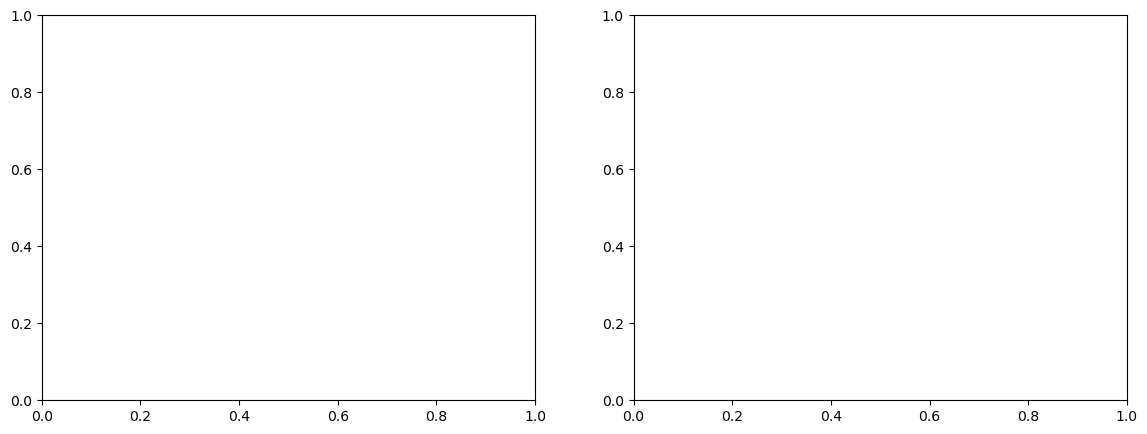

In [80]:
best_model = results[best_model_name]['model']
y_pred = results[best_model_name]['predictions']
y_proba = results[best_model_name]['probabilities']

print(f"\nCLASSIFICATION REPORT - {best_model_name}")
print("="*80)
print(classification_report(
    y_test, y_pred,
    target_names=['Stable', 'Retreating'],
    digits=4
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


✓ Evaluation plots saved: glacier_retreat_evaluation.png


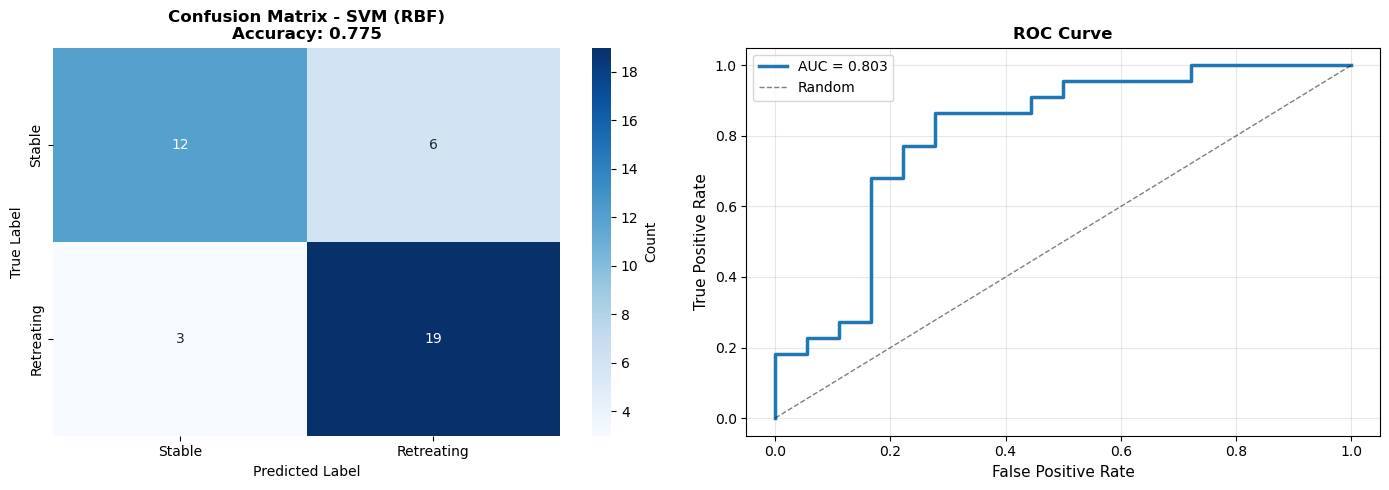

In [86]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stable', 'Retreating'],
    yticklabels=['Stable', 'Retreating'],
    cbar_kws={'label': 'Count'},
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix - {best_model_name}\nAccuracy: {results[best_model_name]["test_acc"]:.3f}', 
                  fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {results[best_model_name]["test_auc"]:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('glacier_retreat_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✓ Evaluation plots saved: glacier_retreat_evaluation.png")

plt.show()